In [1]:
import os
os.environ.setdefault("PYGAME_HIDE_SUPPORT_PROMPT", "1")

import numpy as np
from types import SimpleNamespace

import matplotlib.pyplot as plt
from matplotlib.patches import Circle

import config
from game import Game
from render import Renderer
import config
from env import DanmakuVecEnv

STEPS = 500
SEED = 42

### Raw 좌표 추출 

In [2]:
env = DanmakuVecEnv()
obs, _ = env.reset(seed = SEED)
observations = [obs]
actions = (config.ACTION_RIGHT, config.ACTION_DOWN, config.ACTION_UP, config.ACTION_LEFT)

def get_raw_input(env):
    state = env.game.state
    agent = state.agent 
    raw = np.zeros(env.observation_shape, dtype = np.float32)

    raw[:2] = [agent.x, agent.y]

    sorted_balls = sorted(state.balls, key = lambda ball: (ball.x - agent.x) ** 2 + (ball.y - agent.y))

    for idx, ball in enumerate(sorted_balls[:config.MAX_BALL_NUM]):
        start = env.AGENT_FEATURE_NUM + idx * env.BALL_FEATURE_NUM
        raw[start: start + env.BALL_FEATURE_NUM] = [ball.x, ball.y, ball.vx, ball.vy, 1.0]

    return raw 

### 시각화 + 벡터 값 비교
1. 관측값을 시간순으로 stack
2. 확인할 INDEX 선택
3. 같은 INDEX의 raw와 vec 가져오기
4. raw로 실제 게임 화면 복원
5. vec를 에이전트와 공 단위로 분리
6. 왼쪽에 실제 게임 화면 표시
7. 오른쪽에 [-1,1] 좌표 화면 표시
8. 같은 인덱스의 숫자도 출력

------- transition -------
action: 1 (1:UP, 2:DOWN, 3:LEFT, 4:RIGHT)
score: 182
reward: 1
----------- raw ----------
[590.        570.        171.43932    72.71297    -6.040112   -9.562775
   1.         31.624353   67.955185    4.393415   -2.0553312   1.
  27.723475  534.2391     13.014882   -3.550606    1.         26.32992
  10.005303    6.77664     1.3351011   1.         16.188326  174.35619
  -9.775673    1.8649464   1.          0.          0.          0.       ]
----------- obs -----------
[ 1.          0.9310345  -0.92297125  0.79403085  0.86765885 -0.23670708
  1.         -0.43579894 -0.77046454 -0.40267414 -0.6375183   1.
 -0.96207345 -0.42591125 -0.6517115   0.12432975  1.         -0.90974796
 -0.7865926   0.29289433 -0.13702208  1.         -0.9276952  -0.9830329
  0.451776    0.08900674  1.          0.          0.          0.        ]


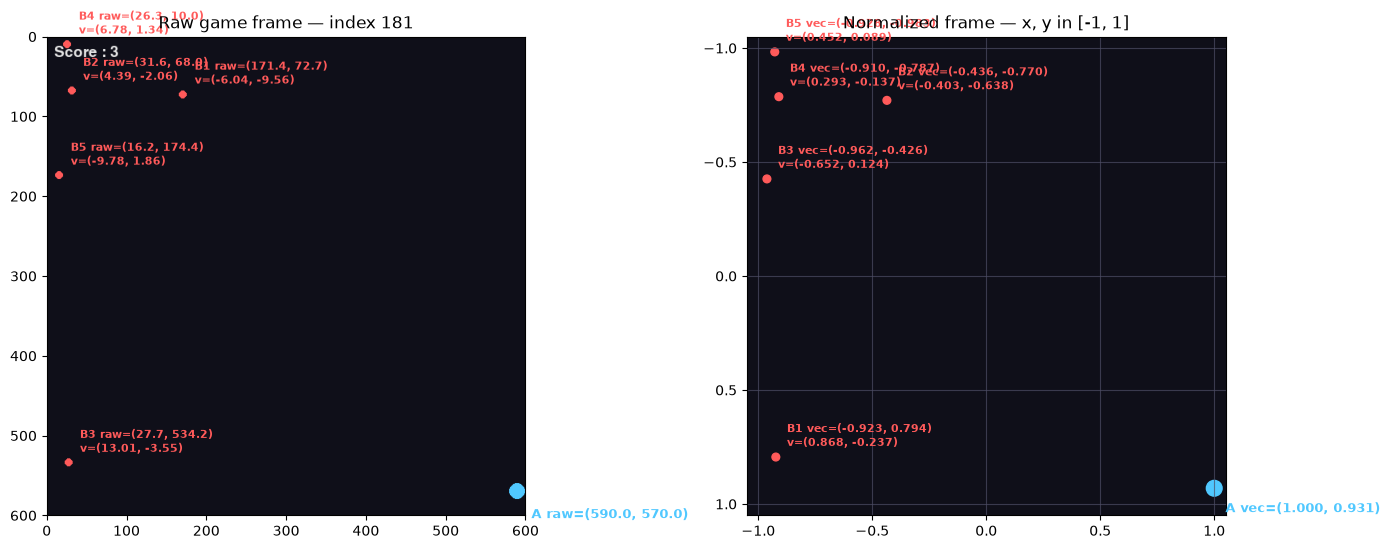

In [3]:

INDEX = 181
raw_inputs = [get_raw_input(env)]
total_reward = 0
for step in range(INDEX+1): 
    action = actions[(step // 30) % len(actions)]
    obs, reward, terminated, truncated, _ = env.step(action)
    observations.append(obs)
    raw_inputs.append(get_raw_input(env))
    total_reward+=reward
    if terminated or truncated: 
        break 


stacked_observations = np.stack(observations, axis=0)
stacked_raw_inputs = np.stack(raw_inputs, axis=0)
raw = stacked_raw_inputs[INDEX]
vec = stacked_observations[INDEX]


# --------------------------------------------------
# 1. raw 값으로 실제 게임 화면 복원
# --------------------------------------------------

game = Game()

game.state.agent.x = float(raw[0])
game.state.agent.y = float(raw[1])
game.state.steps = INDEX
game.state.score = INDEX // config.SCORE_INTERVAL
game.state.alive = True
game.state.balls = []

raw_balls = raw[2:].reshape(config.MAX_BALL_NUM, 5,)

for ball_x, ball_y, ball_vx, ball_vy, mask in raw_balls:
    if mask == 0:
        continue

    game.state.balls.append(SimpleNamespace(
            x=float(ball_x),
            y=float(ball_y),
            vx=float(ball_vx),
            vy=float(ball_vy),
            r=config.BALL_RADIUS,))

renderer = Renderer(render_mode="rgb_array")
raw_image = renderer.get_image(
    game,
    view_score=True,
)
renderer.close()

# --------------------------------------------------
# 2. 정규화 벡터 준비
# --------------------------------------------------

vec_balls = vec[2:].reshape( config.MAX_BALL_NUM, 5, )
active_ball_count = int( np.count_nonzero(vec_balls[:, 4]) )

agent_color = ( np.asarray(config.AGENT_COLOR) / 255.0 )
ball_color = ( np.asarray(config.BALL_COLOR) / 255.0 )
background_color = ( np.asarray(config.BACKGROUND_COLOR) / 255.0 )

# 정규화 좌표계에서의 반지름 (시각화를 용이하게 하기 위해)
agent_normalized_radius = ( 2.0 * config.AGENT_RADIUS / ( config.SCREEN_WIDTH - 2 * config.AGENT_RADIUS ))
ball_normalized_radius = ( 2.0 * config.BALL_RADIUS / (config.SCREEN_WIDTH - 2 * config.BALL_RADIUS))

# --------------------------------------------------
# 3. 원본 화면과 정규화 화면을 바로 시각화
# --------------------------------------------------

fig, (ax_raw, ax_vec) = plt.subplots(1, 2, figsize=(14, 7),)

# 왼쪽: 실제 게임 화면
ax_raw.imshow(raw_image)
ax_raw.set_title(
    f"Raw game frame — index {INDEX}"
)
ax_raw.set_xlim(0, config.SCREEN_WIDTH)
ax_raw.set_ylim(config.SCREEN_HEIGHT, 0)
ax_raw.set_aspect("equal")

ax_raw.annotate((
        f"A raw=({raw[0]:.1f}, {raw[1]:.1f})\n"
    ),
    (raw[0], raw[1]),
    xytext=(10, -30),
    textcoords="offset points",
    color=agent_color,
    fontsize=9,
    weight="bold",
)

for index in range(active_ball_count):
    ball = raw_balls[index]

    ax_raw.annotate((
            f"B{index + 1} "
            f"raw=({ball[0]:.1f}, {ball[1]:.1f})\n"
            f"v=({ball[2]:.2f}, {ball[3]:.2f})" ),
        (ball[0], ball[1]),
        xytext=(8, 8),
        textcoords="offset points",
        color=ball_color,
        fontsize=8,
        weight="bold", )

# 오른쪽: [-1, 1] 정규화 좌표계
ax_vec.set_facecolor(background_color)
ax_vec.set_title( "Normalized frame — x, y in [-1, 1]")
ax_vec.set_xlim(-1.05, 1.05)

# Pygame과 동일하게 아래쪽으로 갈수록 y 증가
ax_vec.set_ylim(1.05, -1.05)

ax_vec.set_aspect("equal")
ax_vec.set_xticks([-1, -0.5, 0, 0.5, 1])
ax_vec.set_yticks([-1, -0.5, 0, 0.5, 1])
ax_vec.grid(True, color=(0.3, 0.3, 0.4), alpha=0.7,)

# 정규화 에이전트
agent_circle = Circle( (vec[0], vec[1]), radius=agent_normalized_radius, color=agent_color,)

ax_vec.add_patch(agent_circle)

ax_vec.annotate((
        f"A vec=({vec[0]:.3f}, {vec[1]:.3f})\n"),
    (vec[0], vec[1]),
    xytext=(8, -28),
    textcoords="offset points",
    color=agent_color,
    fontsize=9,
    weight="bold",)

# 정규화 공
for index in range(active_ball_count):
    ball = vec_balls[index]
    ball_circle = Circle((ball[0], ball[1]), radius=ball_normalized_radius, color=ball_color,)
    ax_vec.add_patch(ball_circle)
    ax_vec.annotate((
            f"B{index + 1} "
            f"vec=({ball[0]:.3f}, {ball[1]:.3f})\n"
            f"v=({ball[2]:.3f}, {ball[3]:.3f})"),
        (ball[0], ball[1]),
        xytext=(8, 8),
        textcoords="offset points",
        color=ball_color,
        fontsize=8,
        weight="bold",)
#=================================================== Visualize ===================================================

print("------- transition -------")

print("action:", action, "(1:UP, 2:DOWN, 3:LEFT, 4:RIGHT)")
print("score:", total_reward)
print("reward:", reward)


print("----------- raw ----------")
print(stacked_raw_inputs[INDEX][:30])
print("----------- obs -----------")
print(stacked_observations[INDEX][:30])
plt.tight_layout()
plt.show()
